In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Make plots look nice
plt.style.use('seaborn-v0_8')
%matplotlib inline

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [3]:
# Load the financial news dataset
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')  
df = df.drop(columns=['Unnamed: 0'])

# Preview the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1407328, 5)

First 5 rows:


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:
print("=== DATASET INFO ===")
print(f"Total articles: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

=== DATASET INFO ===
Total articles: 1407328

Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

Data types:
Unnamed: 0    int64
headline        str
url             str
publisher       str
date            str
stock           str
dtype: object

Missing values:
Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64


=== HEADLINE LENGTH STATISTICS ===
       headline_length    word_count
count     1.407328e+06  1.407328e+06
mean      7.312051e+01  1.141671e+01
std       4.073531e+01  6.352997e+00
min       3.000000e+00  1.000000e+00
25%       4.700000e+01  7.000000e+00
50%       6.400000e+01  1.000000e+01
75%       8.700000e+01  1.300000e+01
max       5.120000e+02  7.700000e+01


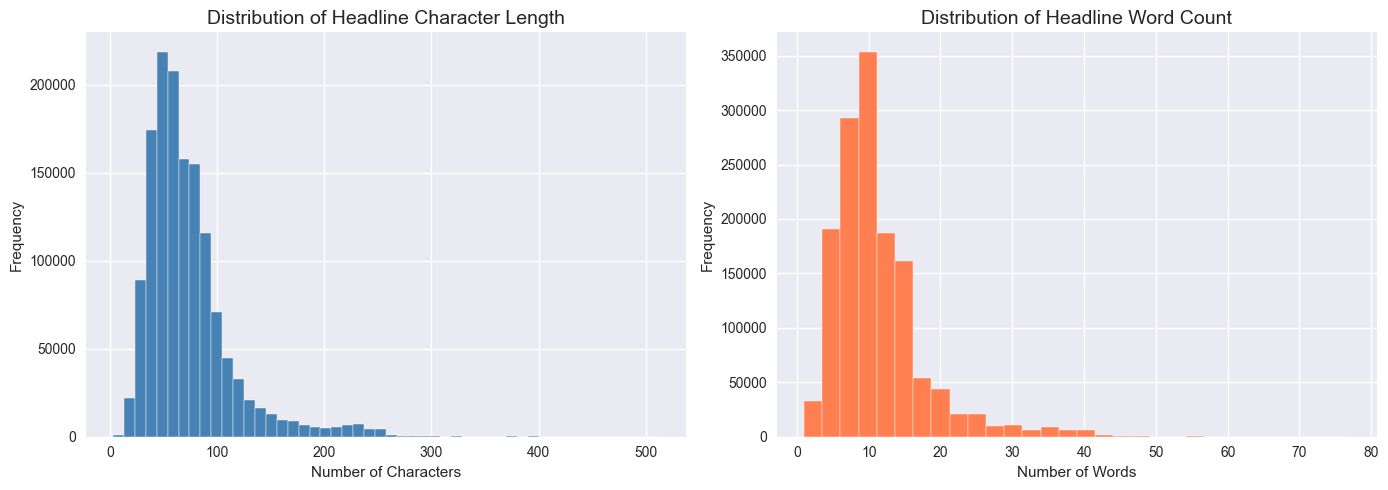

✅ Plot 1 saved!


In [4]:
# Calculate headline length
df['headline_length'] = df['headline'].astype(str).apply(len)
df['word_count'] = df['headline'].astype(str).apply(lambda x: len(x.split()))

print("=== HEADLINE LENGTH STATISTICS ===")
print(df[['headline_length', 'word_count']].describe())

# Plot headline length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['headline_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Headline Character Length', fontsize=14)
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['word_count'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Headline Word Count', fontsize=14)
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../data/raw/headline_length_distribution.png', dpi=150)
plt.show()
print("✅ Plot 1 saved!")

=== TOP 20 PUBLISHERS ===
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64


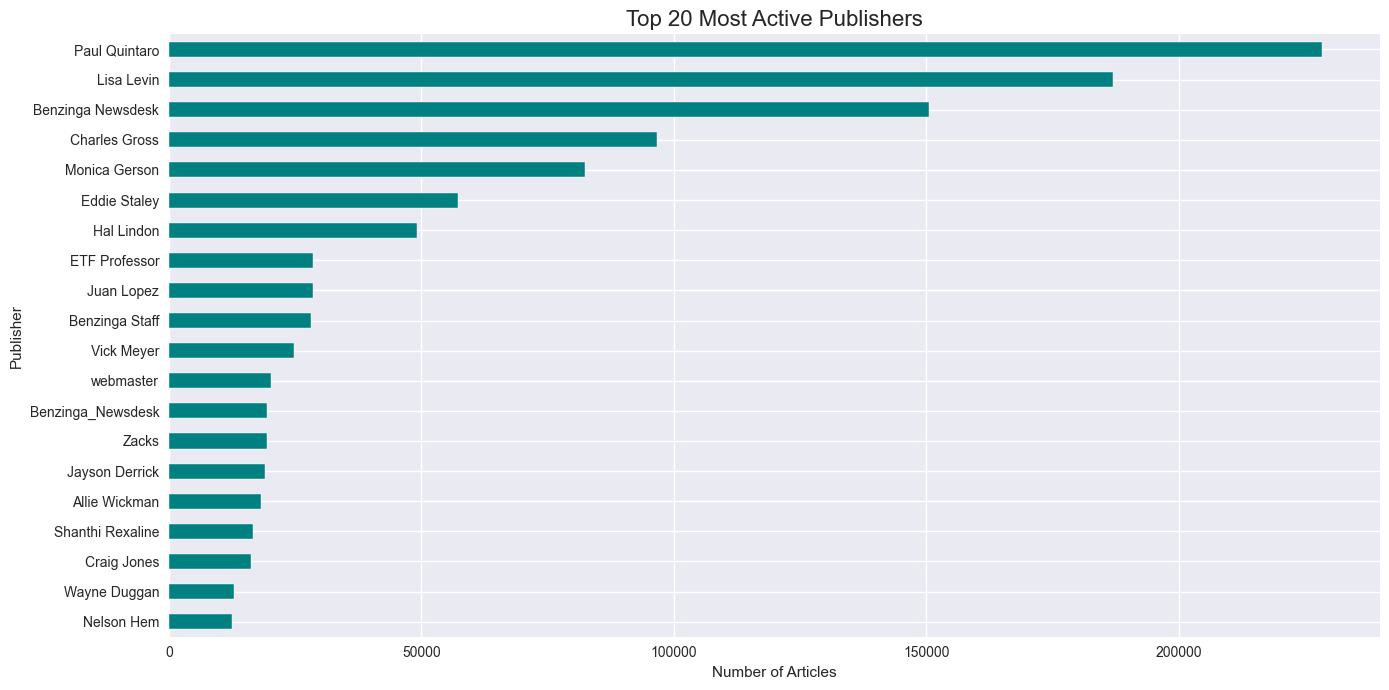

✅ Plot 2 saved!


In [5]:
# Count articles per publisher
publisher_counts = df['publisher'].value_counts().head(20)

print("=== TOP 20 PUBLISHERS ===")
print(publisher_counts)

# Plot
plt.figure(figsize=(14, 7))
publisher_counts.plot(kind='barh', color='teal', edgecolor='white')
plt.title('Top 20 Most Active Publishers', fontsize=16)
plt.xlabel('Number of Articles')
plt.ylabel('Publisher')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/raw/publisher_analysis.png', dpi=150)
plt.show()
print("✅ Plot 2 saved!")

In [6]:
# Parse the date column
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')

# Drop rows where date couldn't be parsed
df = df.dropna(subset=['date'])

# Extract useful time components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()
df['hour'] = df['date'].dt.hour

print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nArticles per year:\n{df['year'].value_counts().sort_index()}")

Date range: 2011-04-28 01:01:48+00:00 to 2020-06-11 21:12:35+00:00

Articles per year:
year
2011      760
2012     1181
2013     1246
2014     1189
2015     3695
2016     4223
2017     3581
2018     5395
2019     6325
2020    28392
Name: count, dtype: int64


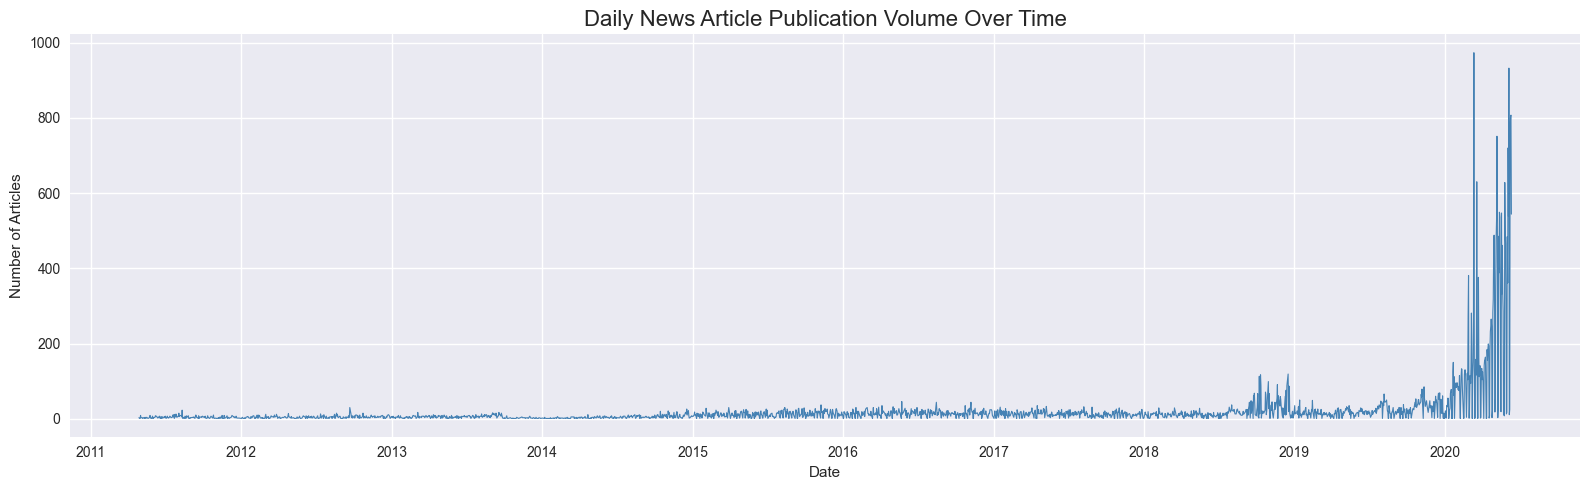

✅ Plot 3 saved!


In [7]:
# Group by date and count articles
daily_counts = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(16, 5))
plt.plot(daily_counts.index, daily_counts.values, color='steelblue', linewidth=0.8)
plt.title('Daily News Article Publication Volume Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.savefig('../data/raw/news_volume_over_time.png', dpi=150)
plt.show()
print("✅ Plot 3 saved!")

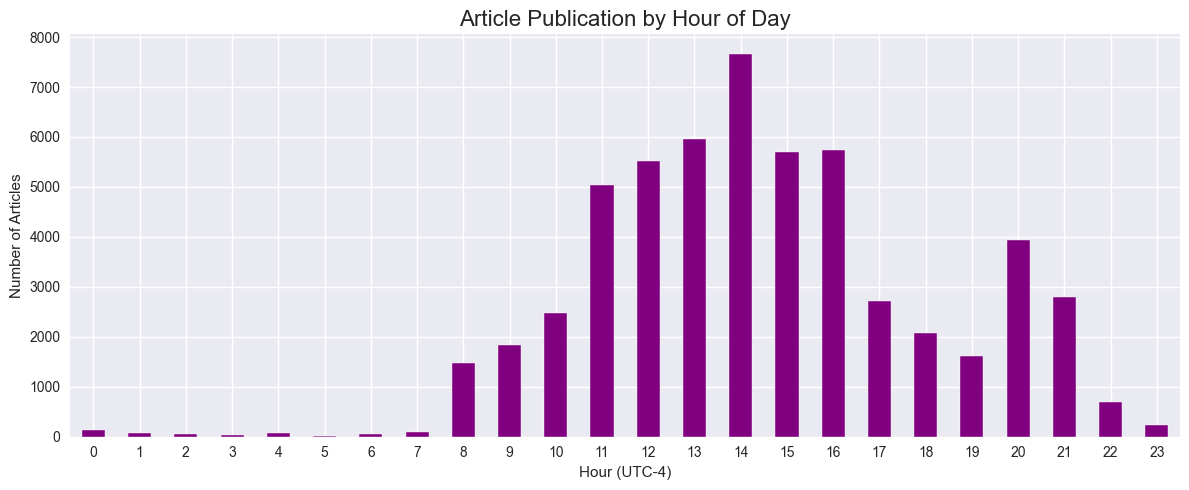

✅ Plot 4 saved!


In [8]:
# What hour of the day are most articles published?
plt.figure(figsize=(12, 5))
df['hour'].value_counts().sort_index().plot(kind='bar', color='purple', edgecolor='white')
plt.title('Article Publication by Hour of Day', fontsize=16)
plt.xlabel('Hour (UTC-4)')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/raw/publishing_hours.png', dpi=150)
plt.show()
print("✅ Plot 4 saved!")

=== TOP 20 KEYWORDS/PHRASES ===
              keyword  count
21             stocks  12794
27               week   9029
0                  52   8453
20             shares   8393
1             52 week   8251
25            trading   6575
7                 hit   5902
22         stocks hit   5847
8              hit 52   5846
4                 eps   5531
11             market   5482
14              price   5046
2           companies   4778
23             target   4676
15       price target   4585
18              sales   4429
6              higher   4271
3   companies trading   4082
5            estimate   3818
9                lows   3741


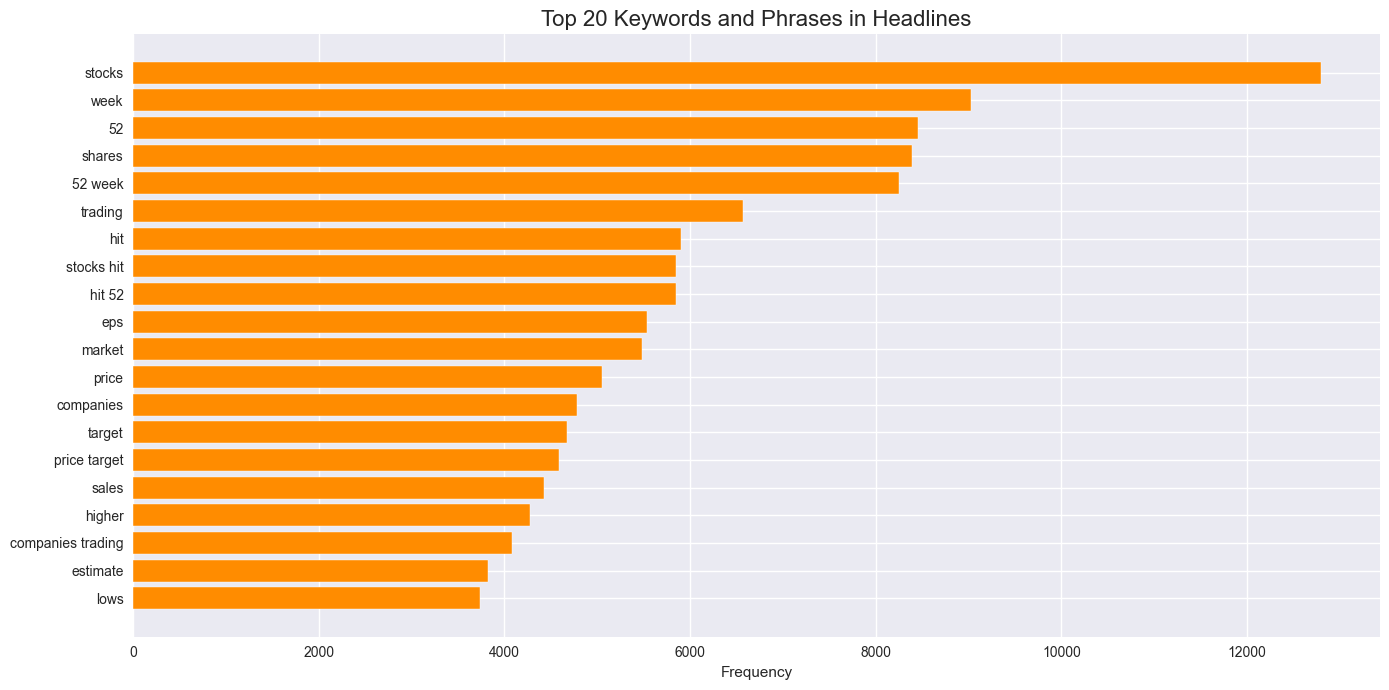

✅ Plot 5 saved!


In [9]:
from sklearn.feature_extraction.text import CountVectorizer

# Extract top keywords from headlines
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=30,
    ngram_range=(1, 2)  # single words and 2-word phrases
)

X = vectorizer.fit_transform(df['headline'].astype(str))
word_counts = X.toarray().sum(axis=0)
keywords = vectorizer.get_feature_names_out()

# Create a sorted dataframe
keyword_df = pd.DataFrame({'keyword': keywords, 'count': word_counts})
keyword_df = keyword_df.sort_values('count', ascending=False).head(20)

print("=== TOP 20 KEYWORDS/PHRASES ===")
print(keyword_df)

# Plot
plt.figure(figsize=(14, 7))
plt.barh(keyword_df['keyword'], keyword_df['count'], color='darkorange', edgecolor='white')
plt.title('Top 20 Keywords and Phrases in Headlines', fontsize=16)
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/raw/top_keywords.png', dpi=150)
plt.show()
print("✅ Plot 5 saved!")

=== TOP 20 MOST COVERED STOCKS ===
stock
A       10
AA      10
AAC     10
AAL     10
AAMC    10
AAME    10
AAN     10
AAOI    10
AAON    10
AAP     10
AAPL    10
AAU     10
AAV     10
AAVL    10
AAWW    10
AB      10
ABAC    10
ABAX    10
ABB     10
ABBV    10
Name: count, dtype: int64


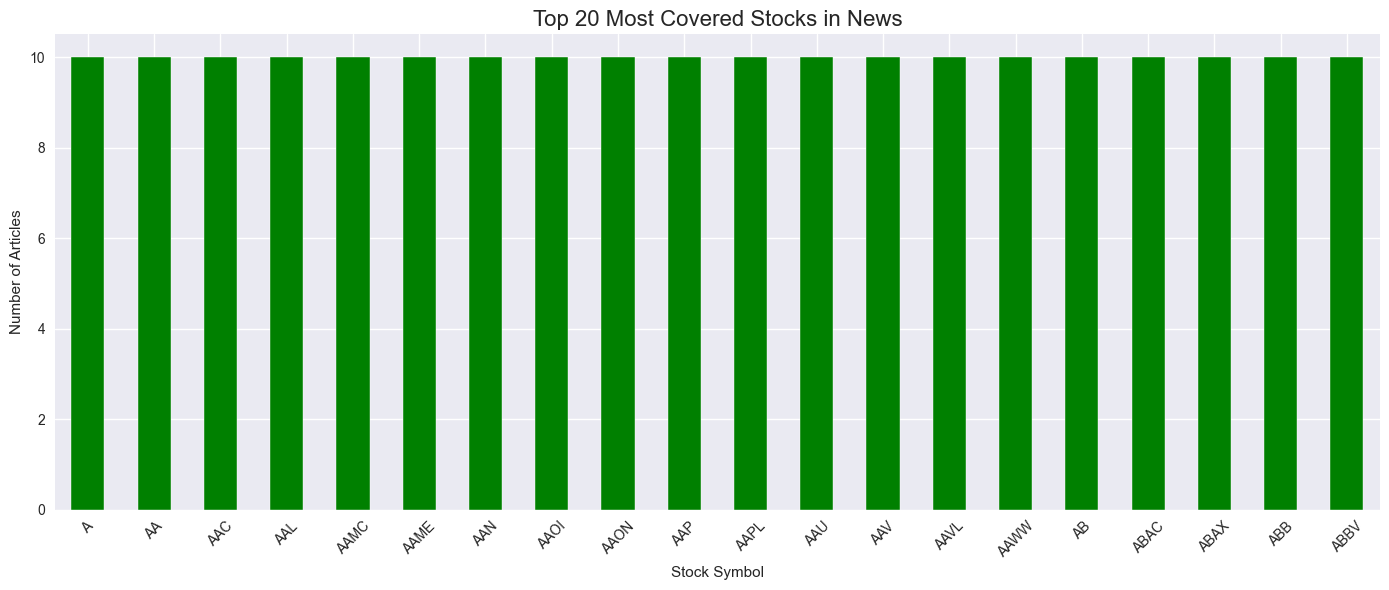

✅ Plot 6 saved!


In [10]:
# Which stocks get the most coverage?
stock_counts = df['stock'].value_counts().head(20)

print("=== TOP 20 MOST COVERED STOCKS ===")
print(stock_counts)

plt.figure(figsize=(14, 6))
stock_counts.plot(kind='bar', color='green', edgecolor='white')
plt.title('Top 20 Most Covered Stocks in News', fontsize=16)
plt.xlabel('Stock Symbol')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/raw/stock_coverage.png', dpi=150)
plt.show()
print("✅ Plot 6 saved!")

In [11]:
# Save the cleaned dataframe for use in later tasks
df.to_csv('../data/raw/cleaned_news.csv', index=False)
print(f"✅ Cleaned data saved! Shape: {df.shape}")
print("\n=== EDA COMPLETE ===")
print(f"Total articles analyzed: {len(df)}")
print(f"Unique publishers: {df['publisher'].nunique()}")
print(f"Unique stocks covered: {df['stock'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

✅ Cleaned data saved! Shape: (55987, 12)

=== EDA COMPLETE ===
Total articles analyzed: 55987
Unique publishers: 225
Unique stocks covered: 6204
Date range: 2011-04-28 to 2020-06-11


In [2]:
import pandas as pd

df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
print("Shape:", df.shape)
print("\nColumn names:", list(df.columns))
print("\nFirst 3 rows:")
df.head(3)

Shape: (1407328, 6)

Column names: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

First 3 rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
